# Predicting Pre-Release Box Office Revenue
**By: Darius Muntean**
An analysis of how production budgets, star power, and franchise IP dictate financial success using Machine Learning.

In [9]:
import pandas as pd
import numpy as np
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

In [10]:
# --- Feature Engineering Setup ---
a_list_actors = [
    'Tom Cruise', 'Robert Downey Jr.', 'Scarlett Johansson', 'Leonardo DiCaprio',
    'Dwayne Johnson', 'Chris Hemsworth', 'Chris Evans', 'Margot Robbie',
    'Tom Hanks', 'Samuel L. Jackson', 'Brad Pitt', 'Zoe Saldana',
    'Will Smith', 'Harrison Ford', 'Jennifer Lawrence', 'Chris Pratt',
    'Johnny Depp', 'Tom Holland', 'Denzel Washington', 'Angelina Jolie',
    'Vin Diesel', 'Bradley Cooper', 'Mark Ruffalo', 'Emma Watson'
]

a_list_directors = [
    'Steven Spielberg', 'James Cameron', 'Christopher Nolan', 'Peter Jackson',
    'Michael Bay', 'J.J. Abrams', 'Ridley Scott', 'Quentin Tarantino',
    'Martin Scorsese', 'Denis Villeneuve', 'David Fincher', 'Zack Snyder'
]

def count_star_power(actor_string):
    if pd.isna(actor_string):
        return 0
    movie_actors = [actor.strip() for actor in actor_string.split(',')]
    star_count = 0
    for actor in movie_actors:
        if actor in a_list_actors:
            star_count += 1
    return star_count

def check_director_power(director_string):
    if pd.isna(director_string):
        return 0
    if director_string.strip() in a_list_directors:
        return 1
    return 0

### 1. Data Cleaning & Feature Engineering
To prevent data leakage, we stripped all post-release metrics (like user reviews) and relied strictly on pre-release data. We also applied a **Logarithmic Transformation** to handle the massive outliers (billion-dollar blockbusters).

In [11]:
# --- Data Loading and Cleaning ---
df = pd.read_csv('data/IMDb movies.csv', low_memory=False)

columns_to_keep = ['title', 'date_published', 'genre', 'budget', 'worlwide_gross_income', 'metascore', 'production_company','actors', 'director']
df = df[columns_to_keep]

df = df.dropna(subset=['budget', 'worlwide_gross_income', 'metascore'])

df = df[df['budget'].str.contains(r'\$', na=False)]
df = df[df['worlwide_gross_income'].str.contains(r'\$', na=False)]

# Convert text to standard float numbers
df['budget'] = df['budget'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float)
df['worlwide_gross_income'] = df['worlwide_gross_income'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float)

# Logarithmic Transformation
# Applies np.log1p (log base e + 1) to normalize skewed data
df['budget'] = np.log1p(df['budget'])
df['worlwide_gross_income'] = np.log1p(df['worlwide_gross_income'])

# Date parsing
df['date_published'] = pd.to_datetime(df['date_published'], errors='coerce')
df = df.dropna(subset=['date_published'])
df['release_month'] = df['date_published'].dt.month
df = df.drop('date_published', axis=1)

# Taming Studios and Genres
top_10_studios = df['production_company'].value_counts().nlargest(10).index
df['production_company'] = df['production_company'].apply(lambda x: x if x in top_10_studios else 'Other')

studio_dummies = pd.get_dummies(df['production_company'], prefix='studio')
genre_dummies = df['genre'].str.get_dummies(sep=', ')

df = pd.concat([df, studio_dummies, genre_dummies], axis=1)
df = df.drop(['production_company', 'genre'], axis=1)

# Applying Star Power
df['star_actor_count'] = df['actors'].apply(count_star_power)
df['has_star_director'] = df['director'].apply(check_director_power)
df = df.drop(['actors', 'director'], axis=1)

# Searches the title for any digit (\d) or a colon (:) which usually denotes a sequel/universe
df['is_franchise'] = df['title'].apply(lambda x: 1 if re.search(r'([:\d])', str(x)) else 0)

# Define X and y
X = df.drop(['worlwide_gross_income', 'title'], axis=1)
y = df['worlwide_gross_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 2. The Algorithm Showdown: Linear Regression vs. Random Forest
We will test a standard Linear Regression model against a Hyperparameter-Tuned Random Forest.

In [12]:
print("--- Baseline: Linear Regression ---")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_log = lr_model.predict(X_test)
lr_pred_dollars = np.expm1(lr_pred_log)

lr_mae = mean_absolute_error(np.expm1(y_test), lr_pred_dollars)
lr_r2 = r2_score(np.expm1(y_test), lr_pred_dollars)

print(f"Linear Regression MAE: ${lr_mae:,.2f}")
print(f"Linear Regression R-Squared: {lr_r2:.4f}")

--- Baseline: Linear Regression ---
Linear Regression MAE: $59,390,422.25
Linear Regression R-Squared: 0.2666


In [13]:
# K-Fold Cross Validation
baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores = cross_val_score(baseline_rf, X_train, y_train, cv=5, scoring='r2')
print(f"Average CV R-squared Score: {cv_scores.mean():.4f}")

# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

tuner = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)
tuner.fit(X_train, y_train)

best_rf_model = tuner.best_estimator_
print(f"Best settings found: {tuner.best_params_}")

# --- Final Evaluation ---
y_pred_log = best_rf_model.predict(X_test)

# Reverse the logarithmic transformation
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)

# Calculate final scores using real dollars
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
r2 = r2_score(y_test_dollars, y_pred_dollars)

print("\n--- Final Model Results ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Average CV R-squared Score: 0.5593
Best settings found: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}

--- Final Model Results ---
Mean Absolute Error (MAE): $51,015,674.48
R-squared Score: 0.6083


### 3. Visualizing the Insights
To understand the mechanics behind our predictions, we extract the **Feature Importances** from our Random Forest. This reveals which data points carry the most mathematical weight when predicting box office revenue. We also visualize the performance gap between our baseline and tuned models.

Generating presentation visuals...


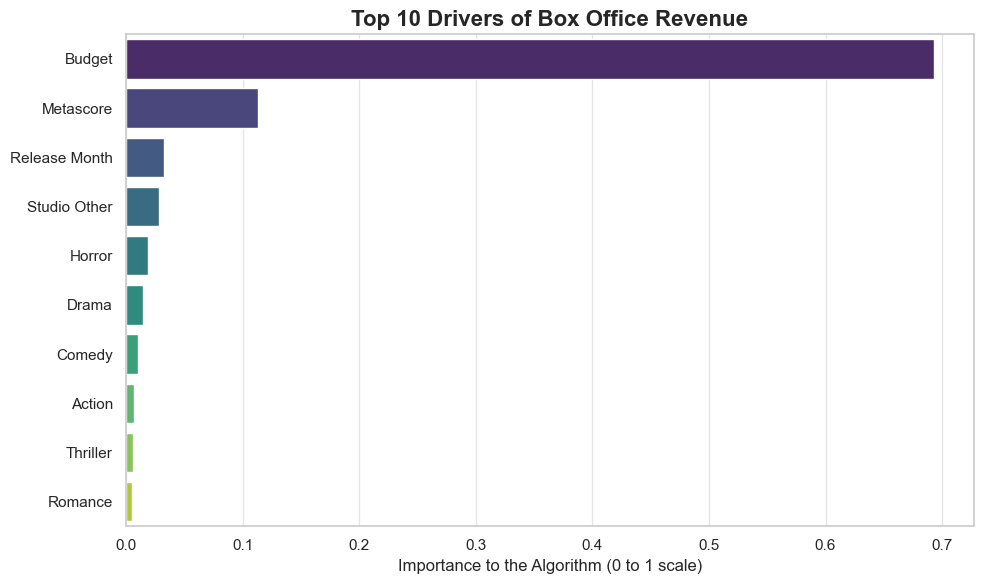

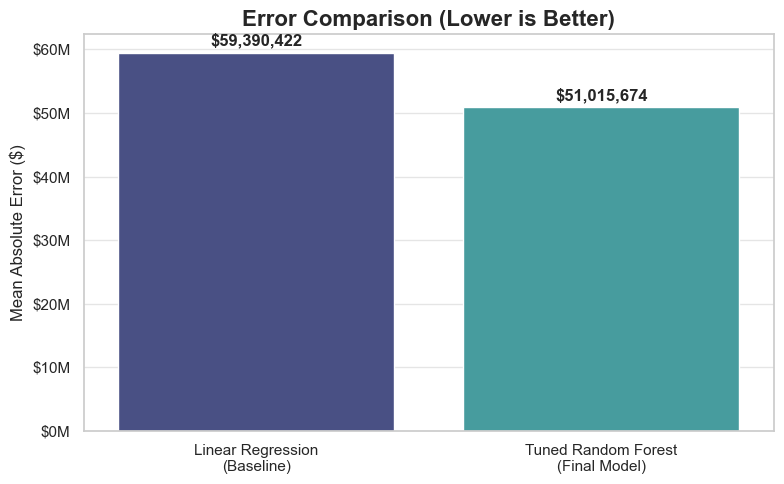

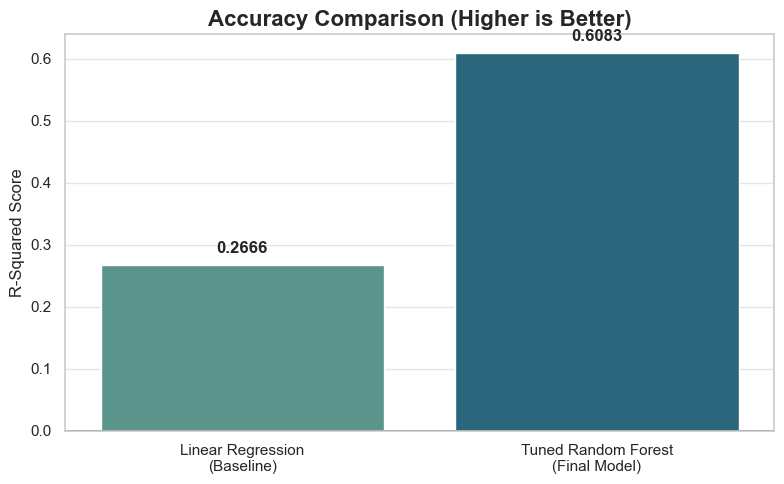

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Generating presentation visuals...")

# ==========================================
# CHART 1: Feature Importance
# ==========================================
plt.figure(figsize=(10, 6))

importances = best_rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)
importance_df['Feature'] = importance_df['Feature'].str.replace('is_', '').str.replace('_', ' ').str.title()

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Drivers of Box Office Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Importance to the Algorithm (0 to 1 scale)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: Model Comparison (Mean Absolute Error)
# ==========================================
plt.figure(figsize=(8, 5))

models = ['Linear Regression\n(Baseline)', 'Tuned Random Forest\n(Final Model)']
maes = [lr_mae, mae]

ax = sns.barplot(x=models, y=maes, palette='mako')
plt.title('Error Comparison (Lower is Better)', fontsize=16, fontweight='bold')
plt.ylabel('Mean Absolute Error ($)', fontsize=12)

ylabels = ['${:,.0f}M'.format(y/1000000) for y in ax.get_yticks()]
ax.set_yticklabels(ylabels)

for index, value in enumerate(maes):
    plt.text(index, value + (value*0.02), f'${value:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Model Comparison (R-Squared)
# ==========================================
plt.figure(figsize=(8, 5))

r2_scores = [lr_r2, r2]

# Using 'crest' palette to visually distinguish it from the MAE chart
ax2 = sns.barplot(x=models, y=r2_scores, palette='crest')
plt.title('Accuracy Comparison (Higher is Better)', fontsize=16, fontweight='bold')
plt.ylabel('R-Squared Score', fontsize=12)

# Add a black line at 0 just in case the Linear Regression scored negatively!
plt.axhline(0, color='black', linewidth=1.2)

# Add the exact scores on top of the bars
for index, value in enumerate(r2_scores):
    # If LR is negative, we drop the text slightly below the line so it doesn't overlap
    offset = 0.02 if value > 0 else -0.05
    plt.text(index, value + offset, f'{value:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()